In [49]:
# Imports e configuração
import io
import os
import sys
import zipfile
import warnings

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

import requests
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from analise_liquidez.dados import ACOES_SCHEMA, ajustar_tipos

# Imports unificados e setup
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
from bizdays import Calendar
import plotly.express as px
import plotly.graph_objects as go

from analise_liquidez.dados import DEBENTURES_SCHEMA, carregar_dados_resiliente, ajustar_tipos
from analise_liquidez.regras import expandir_dias_uteis, filtrar_periodo_recente, calcular_medias_e_volumes, calcular_liquidez_carteira
from analise_liquidez.graficos import plot_titulo_plotly


# Layout COTAHIST (largura fixa) — B3
URL_FORMAT = "https://bvmf.bmfbovespa.com.br/InstDados/SerHist/COTAHIST_A{ano}.ZIP"
COTAHIST_WIDTHS = [2, 8, 2, 12, 3, 12, 10, 3, 4, 13, 13, 13, 13, 13, 13, 13, 5, 18, 18, 13, 1, 8, 7, 13, 12, 3]
COTAHIST_FIELDS = [
    "regtype", "refdate", "bdi_code", "symbol", "instrument_market", "corporation_name", "specification_code",
    "days_to_settlement", "trading_currency", "open", "high", "low", "average", "close", "best_bid", "best_ask",
    "trade_quantity", "traded_contracts", "volume", "strike_price", "strike_price_adjustment_indicator",
    "maturity_date", "allocation_lot_size", "strike_price_in_points", "isin", "distribution_id",
]
HEADERS_HTTP = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36",
    "Accept": "text/plain, */*",
    "Referer": "https://www.b3.com.br/",
    "Origin": "https://www.b3.com.br",
}

In [50]:
# Funções de download, parsing FWF e tratamento dos dados
def decode_bytes(content: bytes) -> str:
    """Decodifica o conteúdo bruto do COTAHIST (latin1/cp1252/utf-8)."""
    for enc in ("utf-8-sig", "latin1", "cp1252"):
        try:
            return content.decode(enc)
        except UnicodeDecodeError:
            continue
    return content.decode("utf-8", errors="replace")


def baixar_cotahist(ano: int) -> pd.DataFrame:
    """Baixa o COTAHIST anual da B3 e retorna os registros de negócios (regtype 01)."""
    url = URL_FORMAT.format(ano=ano)
    print(f"Baixando {url}")
    resp = requests.get(url, headers=HEADERS_HTTP, timeout=600)
    resp.raise_for_status()
    print(f"  {len(resp.content) / 1e6:.1f} MB recebidos")

    frames = []
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        for info in zf.infolist():
            if info.is_dir() or info.file_size == 0:
                continue
            text = decode_bytes(zf.read(info.filename))
            df = pd.read_fwf(
                io.StringIO(text),
                widths=COTAHIST_WIDTHS,
                names=COTAHIST_FIELDS,
                dtype=str,
                header=None,
                skiprows=1,  # pula o cabeçalho (regtype 00)
            )
            df = df[df["regtype"] == "01"].copy()
            print(f"  {info.filename}: {len(df):,} registros de negócios")
            frames.append(df)
    return pd.concat(frames, ignore_index=True)


def tratar_acoes(df: pd.DataFrame) -> pd.DataFrame:
    """Filtra ações à vista em lote padrão e converte tipos/preços."""
    df = df[(df["instrument_market"] == "010") & (df["bdi_code"] == "02")].copy()
    # Exclui ETFs/FIIs que negociam à vista: mantém apenas spec ON/PN/UNT (ações e units)
    spec = df["specification_code"].str.strip().str.upper()
    df = df[spec.str.startswith(("ON", "PN", "UNT"))].copy()
    df = df.rename(columns={
        "refdate": "data_referencia",
        "symbol": "codigo_ativo",
        "isin": "isin",
        "open": "preco_abertura",
        "high": "preco_maximo",
        "low": "preco_minimo",
        "average": "preco_medio",
        "close": "preco_ultimo",
        "trade_quantity": "trad_qty",
        "traded_contracts": "fin_instrm_qty",
        "volume": "ntl_fin_vol",
    })
    # Preços e volume financeiro vêm em centavos -> ÷100.
    # O sentinela "-1" (sem dado) vira NaN via to_numeric(errors='coerce').
    for col in ACOES_SCHEMA["price_cols"]:
        df[col] = pd.to_numeric(df[col], errors="coerce") / 100
    df["ntl_fin_vol"] = pd.to_numeric(df["ntl_fin_vol"], errors="coerce") / 100

    df = ajustar_tipos(df, ACOES_SCHEMA)
    colunas = ["data_referencia", "codigo_ativo", "isin"] + ACOES_SCHEMA["price_cols"] + \
              ACOES_SCHEMA["int_cols"] + ["ntl_fin_vol"]
    df = df[colunas]

    # Checagem defensiva: COTAHIST já é único por ativo/dia
    df = df.drop_duplicates(subset=["data_referencia", "codigo_ativo"], keep="last")
    return df.sort_values(["codigo_ativo", "data_referencia"]).reset_index(drop=True)


def carregar_cotahist(anos: list, cache_path: str) -> pd.DataFrame:
    """Baixa os anos solicitados (com cache local) e retorna as ações tratadas."""
    if os.path.exists(cache_path):
        print(f"Usando cache local: {cache_path}")
        df = pd.read_csv(cache_path, compression="gzip", dtype=str, low_memory=False)
        df = ajustar_tipos(df, ACOES_SCHEMA)
        df["ntl_fin_vol"] = pd.to_numeric(df["ntl_fin_vol"], errors="coerce").fillna(0.0)
        return df.sort_values(["codigo_ativo", "data_referencia"]).reset_index(drop=True)

    df_bruto = pd.concat([baixar_cotahist(a) for a in anos], ignore_index=True)
    df = tratar_acoes(df_bruto)
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    df.to_csv(cache_path, index=False, compression="gzip")
    print(f"Cache salvo em: {cache_path}")
    return df


In [51]:
# Download (primeira execução) ou cache local — ano 2026
ANOS = [2026]
DIR_CACHE = os.path.join(os.path.abspath(".."), "data")
CACHE_PATH = os.path.join(DIR_CACHE, f"cotahist_acoes_{ANOS[0]}_{ANOS[-1]}.csv.gz")

df_acoes = carregar_cotahist(ANOS, CACHE_PATH)

print(f"Período: {df_acoes['data_referencia'].min().date()} a "
      f"{df_acoes['data_referencia'].max().date()}")
print(f"Tickers analisados: {df_acoes['codigo_ativo'].nunique():,}")
print(f"Linhas: {len(df_acoes):,} | Dias de negociação: {df_acoes['data_referencia'].nunique()}")
display(df_acoes.head())

Usando cache local: /home/jovyan/analise_liquidez_ativos/data/cotahist_acoes_2026_2026.csv.gz
Período: 2026-01-02 a 2026-07-31
Tickers analisados: 407
Linhas: 47,202 | Dias de negociação: 145


,data_referencia,codigo_ativo,isin,preco_abertura,preco_minimo,preco_maximo,preco_medio,preco_ultimo,trad_qty,fin_instrm_qty,ntl_fin_vol
0,2026-01-02,AALR3,BRAALRACNOR6,5.04,4.65,5.05,4.73,4.65,136,44800,"212,093.00"
1,2026-01-05,AALR3,BRAALRACNOR6,4.80,4.66,4.80,4.73,4.70,47,38600,"182,877.00"
2,2026-01-06,AALR3,BRAALRACNOR6,4.76,4.75,4.90,4.84,4.89,59,43500,"210,572.00"
3,2026-01-07,AALR3,BRAALRACNOR6,4.89,4.62,4.90,4.69,4.62,95,21400,"100,465.00"
4,2026-01-08,AALR3,BRAALRACNOR6,4.70,4.59,4.70,4.62,4.60,91,20900,"96,661.00"


In [52]:
# Carrega calendário de negócios ANBIMA e expande o histórico por dia útil
df_adjusted = df_acoes
cal = Calendar.load('ANBIMA')
min_date = df_adjusted['data_referencia'].min()
max_date = df_adjusted['data_referencia'].max()

print(f"Data mínima: {min_date.date()} | Data máxima: {max_date.date()}")

business_days = cal.seq(min_date, max_date)
business_days_ts = pd.to_datetime(business_days)

df_expanded = expandir_dias_uteis(df_adjusted, business_days_ts, ACOES_SCHEMA)

print("DataFrame expandido (primeiras linhas):")
display(df_expanded.head())

Data mínima: 2026-01-02 | Data máxima: 2026-07-31
DataFrame expandido (primeiras linhas):


,data_referencia,codigo_ativo,isin,preco_abertura,preco_minimo,preco_maximo,preco_medio,preco_ultimo,trad_qty,fin_instrm_qty,ntl_fin_vol
0,2026-01-02,AALR3,BRAALRACNOR6,5.04,4.65,5.05,4.73,4.65,136,44800,"212,093.00"
1,2026-01-05,AALR3,BRAALRACNOR6,4.80,4.66,4.80,4.73,4.70,47,38600,"182,877.00"
2,2026-01-06,AALR3,BRAALRACNOR6,4.76,4.75,4.90,4.84,4.89,59,43500,"210,572.00"
3,2026-01-07,AALR3,BRAALRACNOR6,4.89,4.62,4.90,4.69,4.62,95,21400,"100,465.00"
4,2026-01-08,AALR3,BRAALRACNOR6,4.70,4.59,4.70,4.62,4.60,91,20900,"96,661.00"


In [53]:
# Filtro para os últimos 3 meses usando a data de referência padrão de debêntures (julho de 2026)
data_referencia = pd.to_datetime('2026-07-30')
print(f"Data de Referência de Análise: {data_referencia.date()}")

df_analise_recent = filtrar_periodo_recente(df_expanded, data_referencia, months_ago=3, schema=DEBENTURES_SCHEMA)
df_analise_recent = ajustar_tipos(df_analise_recent, ACOES_SCHEMA)

display(df_analise_recent.head())

Data de Referência de Análise: 2026-07-30
DataFrame filtrado para o período: 2026-04-30 a 2026-07-30


,data_referencia,codigo_ativo,isin,preco_abertura,preco_minimo,preco_maximo,preco_medio,preco_ultimo,trad_qty,fin_instrm_qty,ntl_fin_vol
80,2026-04-30,AALR3,BRAALRACNOR6,2.85,2.62,2.98,2.83,2.97,313,85600,"242,392.00"
81,2026-05-04,AALR3,BRAALRACNOR6,2.91,2.81,2.97,2.90,2.97,42,27500,"80,004.00"
82,2026-05-05,AALR3,BRAALRACNOR6,2.95,2.93,3.19,3.08,3.15,118,32400,"100,052.00"
83,2026-05-06,AALR3,BRAALRACNOR6,3.15,3.10,3.23,3.17,3.18,57,84300,"267,745.00"
84,2026-05-07,AALR3,BRAALRACNOR6,3.20,2.97,3.20,3.03,3.03,66,65200,"197,870.00"


In [54]:
# Identificação das debêntures mais negociadas por número de negócios no período recente
top_5_negociados_recentes = df_analise_recent.groupby('isin')['trad_qty'].sum().nlargest(5)
top_5_isins = top_5_negociados_recentes.index.tolist()

top_5_info = df_analise_recent[df_analise_recent['isin'].isin(top_5_isins)][['isin', 'codigo_ativo']].drop_duplicates()
top_5_info = top_5_info.set_index('isin').loc[top_5_isins].reset_index()
top_5_info = top_5_info.merge(top_5_negociados_recentes.rename('trad_qty'), on='isin')

print("Top 5 Mais Negociados:")
display(top_5_info)

Top 5 Mais Negociados:


,isin,codigo_ativo,trad_qty
0,BRPETRACNPR6,PETR4,3261344
1,BRITUBACNPR1,ITUB4,2467942
2,BRB3SAACNOR6,B3SA3,2118626
3,BRVALEACNOR0,VALE3,2079959
4,BRSBSPACNOR5,SBSP3,1959167


In [55]:
# Cálculo das médias móveis de quantidade de 21 dias úteis e volumes de liquidez
df_analise = calcular_medias_e_volumes(df_expanded, ACOES_SCHEMA)
display(df_analise.sort_values(by=['data_referencia', 'quantidade_media_21_dias'], ascending=[False, False]).head())

,data_referencia,codigo_ativo,isin,preco_abertura,preco_minimo,preco_maximo,preco_medio,preco_ultimo,trad_qty,fin_instrm_qty,ntl_fin_vol,quantidade_media_21_dias,valor_total_sem_desconto,volume_liquido_1dia_calculado
144,2026-07-31,AZUL53,BRAZULA01OR8,222.86,211.00,226.00,218.00,215.00,583,3001000000,"656,607.43",3001000000,"654,218,000,000.00","654,218,000,000.00"
144,2026-07-31,RAIZ4,BRRAIZACNPR6,0.27,0.26,0.27,0.26,0.26,2669,4895600,"1,295,266.00",112174457,"29,165,358.82","29,165,358.82"
144,2026-07-31,B3SA3,BRB3SAACNOR6,15.90,15.52,15.90,15.74,15.73,19790,24490400,"385,709,469.00",31161180,"490,476,973.20","490,476,973.20"
144,2026-07-31,PETR4,BRPETRACNPR6,43.00,42.86,43.55,43.36,43.42,45277,24997300,"1,084,118,619.00",29943961,"1,298,370,148.96","1,298,370,148.96"
144,2026-07-31,ABEV3,BRABEVACNOR1,16.10,15.85,16.10,15.99,15.99,19324,38243300,"611,512,781.00",28475433,"455,322,173.67","455,322,173.67"


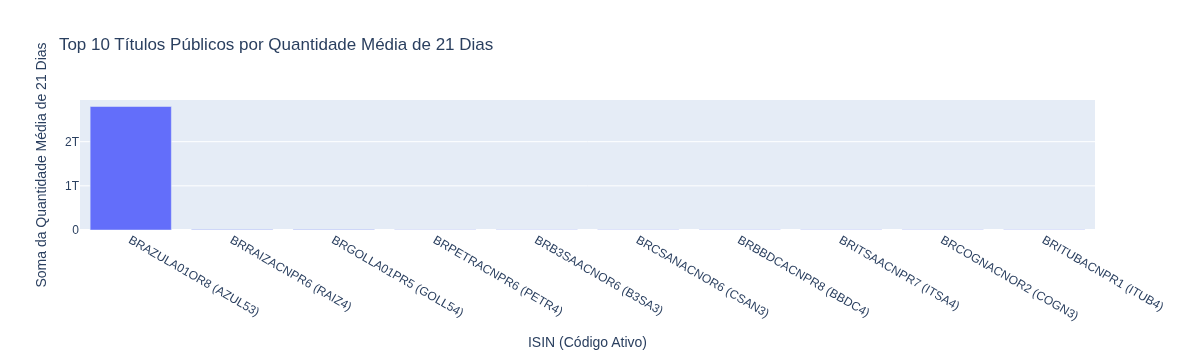

In [64]:
# Gráfico de barras de top 10 ISINs por volume médio diário acumulado
top_10_media_21_dias = df_analise.groupby('isin')['quantidade_media_21_dias'].sum().nlargest(10).reset_index()
top_10_info_media = pd.merge(
    top_10_media_21_dias,
    df_analise[['isin', 'codigo_ativo']].drop_duplicates(),
    on='isin',
    how='left'
)
top_10_info_media['isin_codigo'] = top_10_info_media['isin'] + ' (' + top_10_info_media['codigo_ativo'].astype(str) + ')'

fig_bar = px.bar(
    top_10_info_media,
    x='isin_codigo',
    y='quantidade_media_21_dias',
    title='Top 10 Títulos Públicos por Quantidade Média de 21 Dias',
    labels={'isin_codigo': 'ISIN (Código Ativo)', 'quantidade_media_21_dias': 'Soma da Quantidade Média de 21 Dias'}
)
fig_bar.update_layout(xaxis={'categoryorder':'total descending'})
fig_bar.show()

In [69]:
# Análise de Liquidez de Carteira do Fundo
parametros_calculo = {
    "data_referencia": data_referencia,
    "prazo_de_cotizacao": 1,
    "carteira_de_titulos_publicos": [
        ["BRB3SAACNOR6", "B3SA3", 27048],
        ["BRPETRACNPR6", "PETR4", 27048],
        ["BRABEVACNOR1", "ABEV3", 27048]
    ]
}

df_analise_liquidez_carteira = calcular_liquidez_carteira(
    parametros=parametros_calculo,
    df_dados_liquidez=df_analise,
    schema=ACOES_SCHEMA
)

print("\n--- Resultado da Análise de Liquidez da Carteira ---")
pd.options.display.float_format = '{:,.2f}'.format
display(df_analise_liquidez_carteira.head())


--- Análise de Liquidez para a Carteira do Fundo na data 2026-07-30 ---
  Ativo: B3SA3 (ISIN: BRB3SAACNOR6) - Dados de liquidez encontrados.
  Ativo: PETR4 (ISIN: BRPETRACNPR6) - Dados de liquidez encontrados.
  Ativo: ABEV3 (ISIN: BRABEVACNOR1) - Dados de liquidez encontrados.

--- Resultado da Análise de Liquidez da Carteira ---


,isin,codigo_ativo,quantidade_fundo,data_referencia,preco_medio,liquidez_media_21_dias,volume_liquido_1dia_calculado,valor_total_alocado,valor_total_prazo_cotizacao,valor_total_liquido,percentual_liquido_alocado
0,BRB3SAACNOR6,B3SA3,27048,2026-07-30,15.47,31739476,"491,009,693.72","418,432.56","491,009,693.72","418,432.56",100.00
1,BRPETRACNPR6,PETR4,27048,2026-07-30,42.42,29795938,"1,263,943,689.96","1,147,376.16","1,263,943,689.96","1,147,376.16",100.00
2,BRABEVACNOR1,ABEV3,27048,2026-07-30,15.60,27495119,"428,923,856.40","421,948.80","428,923,856.40","421,948.80",100.00
